### Quntizate embeded MobileNet v3 for object connections

In [36]:
import os
import cv2
import numpy as np
import onnx
from onnxruntime.quantization import CalibrationDataReader, quantize_static, QuantType, QuantFormat
import torchvision.models as models
import torch
from pathlib import Path
from help_fun import plot
from torch import nn
import netron
import onnxruntime as ort

In [18]:
mobilenet = models.mobilenet_v3_small(pretrained=True)

mobilenet.classifier = nn.Sequential(*list(mobilenet.classifier.children())[:-1])

dummy_input = torch.randn(1, 3, 64, 64) 

torch.onnx.export(
    mobilenet,
    dummy_input,
    "onnx_embbeded/mobilenet_v3_small_64x64_embed.onnx",
    input_names=["input"],
    output_names=["output"],
    opset_version=12
)


In [12]:
!python -m onnxruntime.quantization.preprocess --input "onnx_embbeded/mobilenet_v3_small_64x64.onnx" --output 'onnx_embbeded/preprocessed.onnx'

In [22]:
onnx_model_path = 'onnx_embbeded/preprocessed.onnx'
model = onnx.load(onnx_model_path)

onnx.checker.check_model(model)
print('ok')

ok


In [25]:
model_path = 'onnx_embbeded/preprocessed.onnx'
from IPython.display import IFrame

# Uruchamiamy Netron
netron.start(model_path)

IFrame('http://localhost:8080', width=800, height=600)

Serving 'onnx_embbeded/preprocessed.onnx' at http://localhost:8080


In [13]:
folder_path = Path('/home/plorenc/Desktop/ADAS_for_poor/bdd100k_data/bdd100k/bdd100k/images/100k/val')

image_files = [f for f in os.listdir(folder_path) if f.endswith('.png') or f.endswith('.jpg')]

image_paths = [os.path.join(folder_path, i) for i in image_files]

In [61]:
class ImageCalibrationDataReader(CalibrationDataReader):
    def __init__(self, image_paths):
        self.image_paths = image_paths
        self.idx = 0
        self.input_name = "input"

    def preprocess(self, frame):
        image_data = cv2.imread(frame)
        image_data = cv2.resize(image_data, (64, 64))
        image_data = np.array(image_data).astype(np.float32)  # Normalize to [0, 1] range
        image_data = np.transpose(image_data, (2, 0, 1))  # (H, W, C) -> (C, H, W)
        image_data = np.expand_dims(image_data, axis=0)  # Add batch dimension
        return image_data

    def get_next(self):
        if self.idx >= len(self.image_paths):
            return None

        image_path = self.image_paths[self.idx]
        input_data = self.preprocess(image_path)
        self.idx += 1
        return {self.input_name: input_data}


image_files = os.listdir(folder_path)
calibration_image_paths = [os.path.join(folder_path, p) for p in image_files][:2000]

calibration_data_reader = ImageCalibrationDataReader(calibration_image_paths)

quantize_static(
    'onnx_embbeded/preprocessed.onnx',                     
    'onnx_embbeded/mobilenet_v3_small_quantized.onnx', 
    weight_type=QuantType.QInt8,
    activation_type=QuantType.QUInt8,
    calibration_data_reader=calibration_data_reader,
    quant_format=QuantFormat.QDQ,
    per_channel=False,
    nodes_to_exclude=["Conv_0", "Gemm_123"],
    reduce_range=True,)

print("Quantization finished.")


Increasing scale for weight `features.1.block.1.fc2.weight` by the ratio 3973.011078642399 to ensure bias input `features.1.block.1.fc2.bias` has a valid scale.
Increasing scale for weight `features.4.block.2.fc2.weight` by the ratio 1.7183980391497227 to ensure bias input `features.4.block.2.fc2.bias` has a valid scale.


Quantization finished.


In [62]:
def preprocess(frame):
    image_data = cv2.imread(frame)
    image_data = cv2.resize(image_data, (64, 64))
    image_data = np.array(image_data).astype(np.float32)  # Normalize to [0, 1] range
    image_data = np.transpose(image_data, (2, 0, 1))  # (H, W, C) -> (C, H, W)
    image_data = np.expand_dims(image_data, axis=0)  # Add batch dimension
    return image_data

out_before = mobilenet(torch.tensor(preprocess(image_paths[0])))
out_before = out_before.view(32, 32).detach().numpy()

session = ort.InferenceSession('onnx_embbeded/mobilenet_v3_small_64x64_embed.onnx')
out_after = session.run(None, {'input': preprocess(image_paths[0])})[0]
out_after = out_after.reshape(32, 32)

In [63]:
session.get_inputs()[0].name

'input'

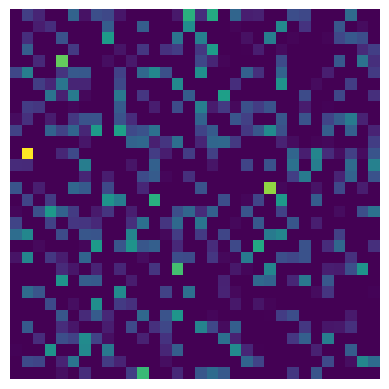

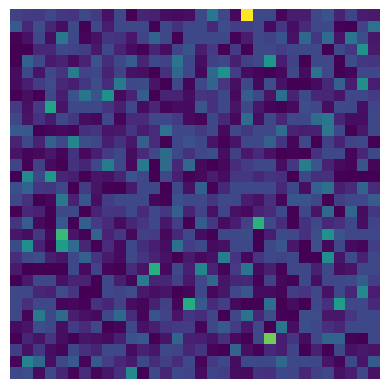

(None, None)

In [64]:
plot(out_after), plot(out_before)